# Funding the Fall: A Two-Component Crypto Perpetual Futures Strategy

**Authors:** John Beecher, Antonio Braz, Jean-Luc Choiseul, Jean Mauratille

**FINM 33150 — Quantitative Trading Strategies** | University of Chicago | 2026

## Abstract

We construct a two-component strategy for crypto perpetual futures that combines
**funding-rate carry** (85% baseline allocation) with **cascade-driven opportunistic
shorts** (up to 15% allocation). The carry leg harvests cross-venue funding spreads on
BTC, ETH, SOL, HYPE, and DOGE across seven exchanges (Hyperliquid, Lighter, OKX, Kraken,
Binance, Bybit, dYdX), maintaining delta neutrality through offsetting long/short
positions. The cascade leg uses a feedback-loop liquidation simulator calibrated to real
open interest data to identify periods of market fragility — when the amplification factor
$A(\delta)$ is high, return distributions become negatively skewed due to forced
liquidation cascades, making short positions positive expected value. In elevated-risk
regimes the strategy scales into shorts on the most fragile coins while simultaneously
reducing carry exposure as a defensive overlay. We backtest with an event-loop engine
operating on 8-hour funding epochs, incorporating Almgren-Chriss transaction costs with
square-root price impact. The combined strategy targets a Sharpe ratio above 2 with
maximum drawdown under 15%.

---
## 1. Setup

In [1]:
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap

from funding_the_fall.data.storage import (
    load_funding,
    load_candles,
    load_oi,
    load_liquidations,
)
from funding_the_fall.models.cascade import (
    Position,
    CascadeResult,
    simulate_cascade,
    compute_amplification_curve,
    cascade_risk_signal,
    build_positions_from_oi,
    sensitivity_to_leverage,
    sensitivity_to_depth,
    DEFAULT_DEPTH_USD,
)
from funding_the_fall.backtest.costs import TransactionCostModel, make_cost_model

# matplotlib defaults
plt.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

COINS = ["BTC", "ETH", "SOL", "HYPE", "DOGE"]
COIN_COLORS = dict(zip(COINS, ["#F7931A", "#627EEA", "#9945FF", "#00D1A0", "#C3A634"]))

In [2]:
funding = load_funding()
candles = load_candles()
oi = load_oi()
liquidations = load_liquidations()

for name, df in [
    ("funding", funding),
    ("candles", candles),
    ("oi", oi),
    ("liquidations", liquidations),
]:
    print(
        f"{name:14s}  {df.shape[0]:>8,} rows x {df.shape[1]} cols  "
        f"[{df['timestamp'].min()} .. {df['timestamp'].max()}]"
    )

funding           29,217 rows x 4 cols  [2025-03-06 08:00:00+00:00 .. 2026-03-05 08:00:00+00:00]
candles          121,122 rows x 8 cols  [2025-03-06 11:00:00+00:00 .. 2026-03-05 11:00:00+00:00]
oi                10,025 rows x 4 cols  [2025-03-06 11:06:00+00:00 .. 2026-03-05 11:05:37.567219+00:00]
liquidations       8,059 rows x 6 cols  [2025-05-25 14:36:58.596000+00:00 .. 2026-03-05 11:18:08.888000+00:00]


---
## 2. Data EDA

We collect four datasets from seven perpetual futures venues via REST APIs and websockets:

| Dataset | Source | Granularity | Key columns |
|---------|--------|-------------|-------------|
| **Funding rates** | All 7 venues | 8-hour epochs | `venue`, `coin`, `funding_rate` |
| **Candles** | All 7 venues | 1-hour OHLCV | `venue`, `coin`, `o/h/l/c/v` |
| **Open interest** | Hyperliquid, Binance, Bybit | ~1-hour snapshots | `venue`, `coin`, `oi_usd` |
| **Liquidations** | Hyperliquid | Tick-level | `venue`, `coin`, `side`, `size_usd`, `price` |

In [3]:
# Dataset summary table
def _summarize(name: str, df: pl.DataFrame) -> dict:
    venues = df["venue"].unique().sort().to_list()
    coins = df["coin"].unique().sort().to_list()
    return {
        "Dataset": name,
        "Rows": f"{df.shape[0]:,}",
        "Columns": df.shape[1],
        "Start": str(df["timestamp"].min())[:10],
        "End": str(df["timestamp"].max())[:10],
        "Venues": ", ".join(venues),
        "Coins": ", ".join(coins),
    }


summary = pd.DataFrame(
    [
        _summarize("Funding", funding),
        _summarize("Candles", candles),
        _summarize("OI", oi),
        _summarize("Liquidations", liquidations),
    ]
)
summary.style.hide(axis="index")

Dataset,Rows,Columns,Start,End,Venues,Coins
Funding,"29,217",4,2025-03-06,2026-03-05,"binance, bybit, dydx, hyperliquid, kraken, lighter, okx","BTC, DOGE, ETH, HYPE, SOL"
Candles,"121,122",8,2025-03-06,2026-03-05,"binance, bybit, dydx, hyperliquid, kraken, lighter, okx","BTC, DOGE, ETH, HYPE, SOL"
OI,"10,025",4,2025-03-06,2026-03-05,"binance, bybit, dydx, hyperliquid, kraken, lighter, okx","BTC, DOGE, ETH, HYPE, SOL"
Liquidations,"8,059",6,2025-05-25,2026-03-05,"hyperliquid, okx","BTC, DOGE, ETH, HYPE, SOL"


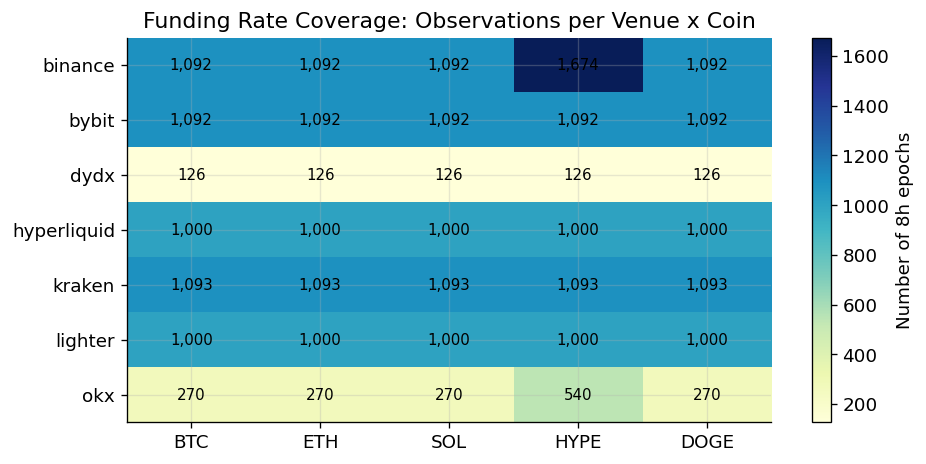

In [4]:
# Time coverage heatmap: funding observations by venue x coin
coverage = (
    funding.group_by(["venue", "coin"])
    .agg(pl.col("funding_rate").count().alias("n_obs"))
    .to_pandas()
    .pivot(index="venue", columns="coin", values="n_obs")
    .fillna(0)
    .astype(int)
)
coverage = coverage.reindex(columns=[c for c in COINS if c in coverage.columns])

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(coverage.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(coverage.columns)))
ax.set_xticklabels(coverage.columns)
ax.set_yticks(range(len(coverage.index)))
ax.set_yticklabels(coverage.index)
for i in range(len(coverage.index)):
    for j in range(len(coverage.columns)):
        ax.text(j, i, f"{coverage.values[i, j]:,}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="Number of 8h epochs")
ax.set_title("Funding Rate Coverage: Observations per Venue x Coin")
fig.tight_layout()
plt.show()

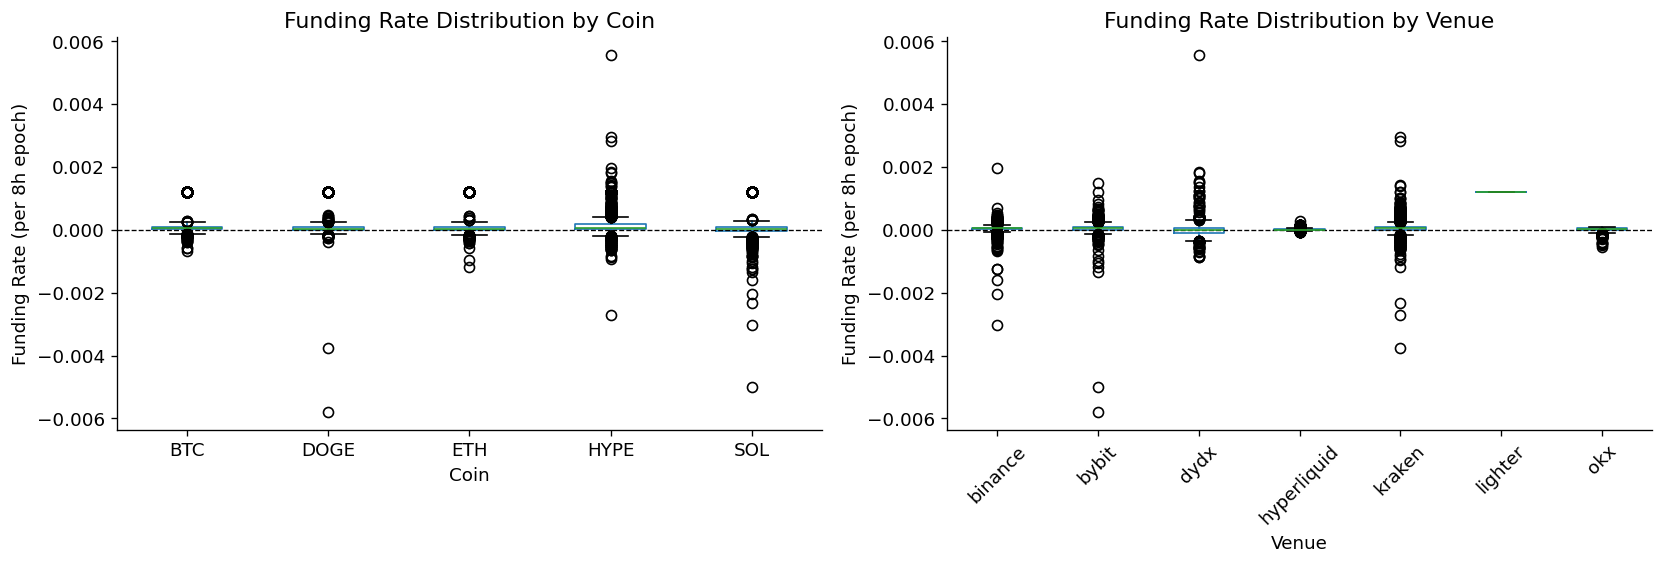

In [5]:
# Funding rate distributions: box plot by coin, then by venue
fund_pd = funding.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By coin
fund_pd.boxplot(column="funding_rate", by="coin", ax=axes[0], grid=False)
axes[0].set_title("Funding Rate Distribution by Coin")
axes[0].set_xlabel("Coin")
axes[0].set_ylabel("Funding Rate (per 8h epoch)")
axes[0].axhline(0, color="black", lw=0.8, ls="--")

# By venue
fund_pd.boxplot(column="funding_rate", by="venue", ax=axes[1], grid=False)
axes[1].set_title("Funding Rate Distribution by Venue")
axes[1].set_xlabel("Venue")
axes[1].set_ylabel("Funding Rate (per 8h epoch)")
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("")
fig.tight_layout()
plt.show()

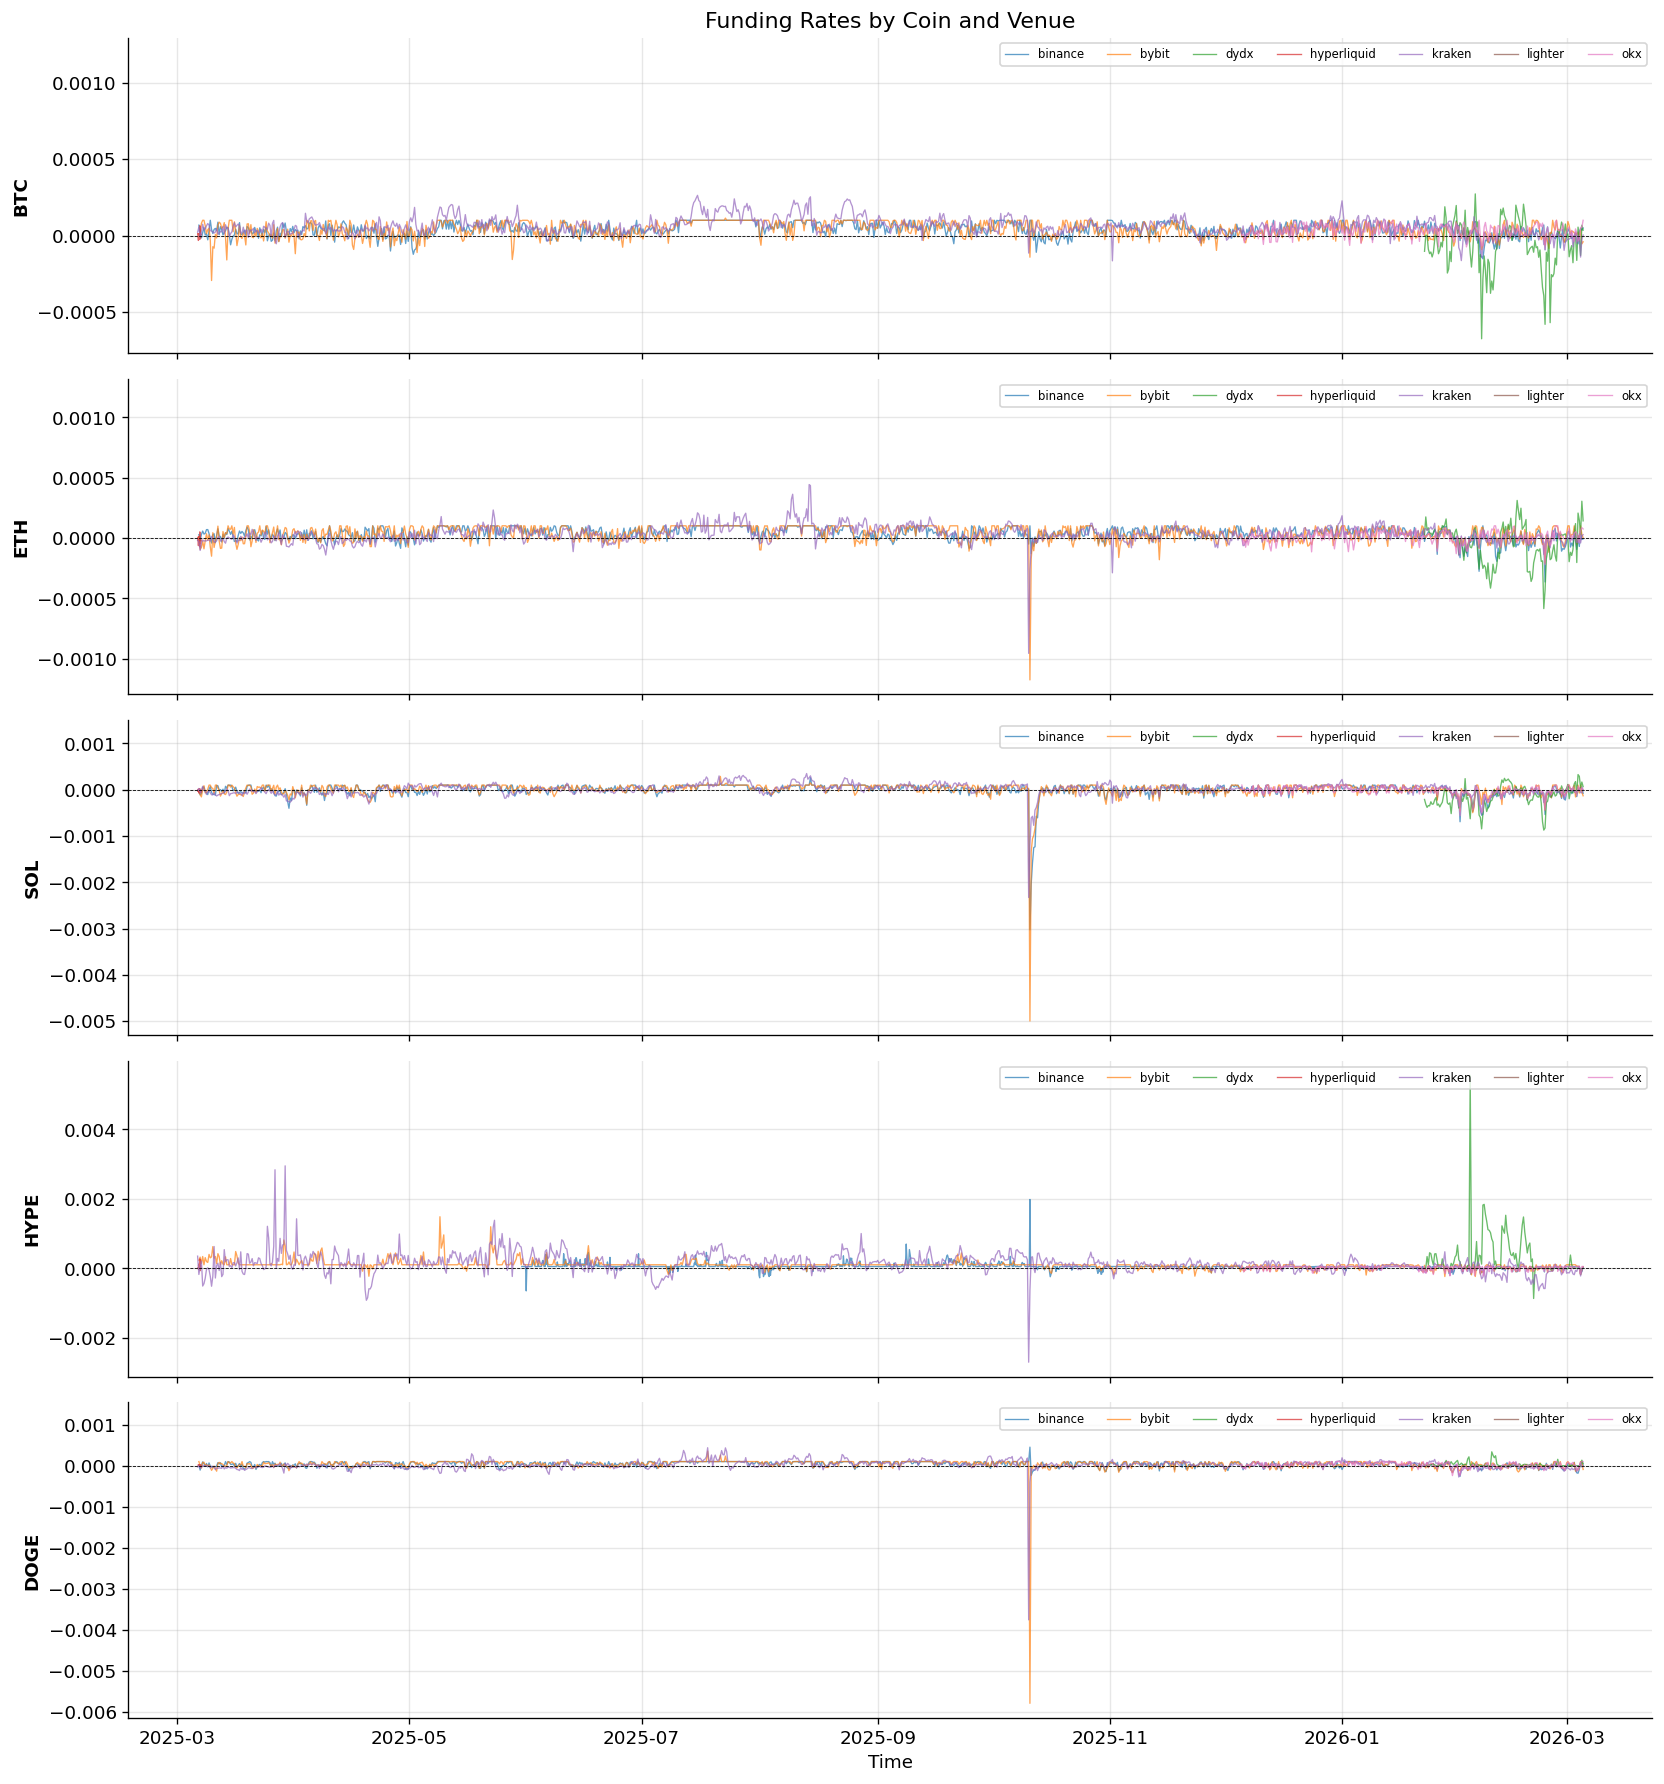

In [6]:
# Funding rate time series per coin, colored by venue
venues = funding["venue"].unique().sort().to_list()
venue_colors = dict(zip(venues, plt.cm.tab10.colors[: len(venues)]))

fig, axes = plt.subplots(len(COINS), 1, figsize=(14, 3 * len(COINS)), sharex=True)
for ax, coin in zip(axes, COINS):
    subset = funding.filter(pl.col("coin") == coin).sort("timestamp").to_pandas()
    for venue in venues:
        vdf = subset[subset["venue"] == venue]
        if vdf.empty:
            continue
        ax.plot(
            vdf["timestamp"],
            vdf["funding_rate"],
            label=venue,
            alpha=0.7,
            lw=0.8,
            color=venue_colors[venue],
        )
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_ylabel(coin, fontweight="bold")
    ax.legend(loc="upper right", fontsize=7, ncol=len(venues))
axes[-1].set_xlabel("Time")
axes[0].set_title("Funding Rates by Coin and Venue")
fig.tight_layout()
plt.show()

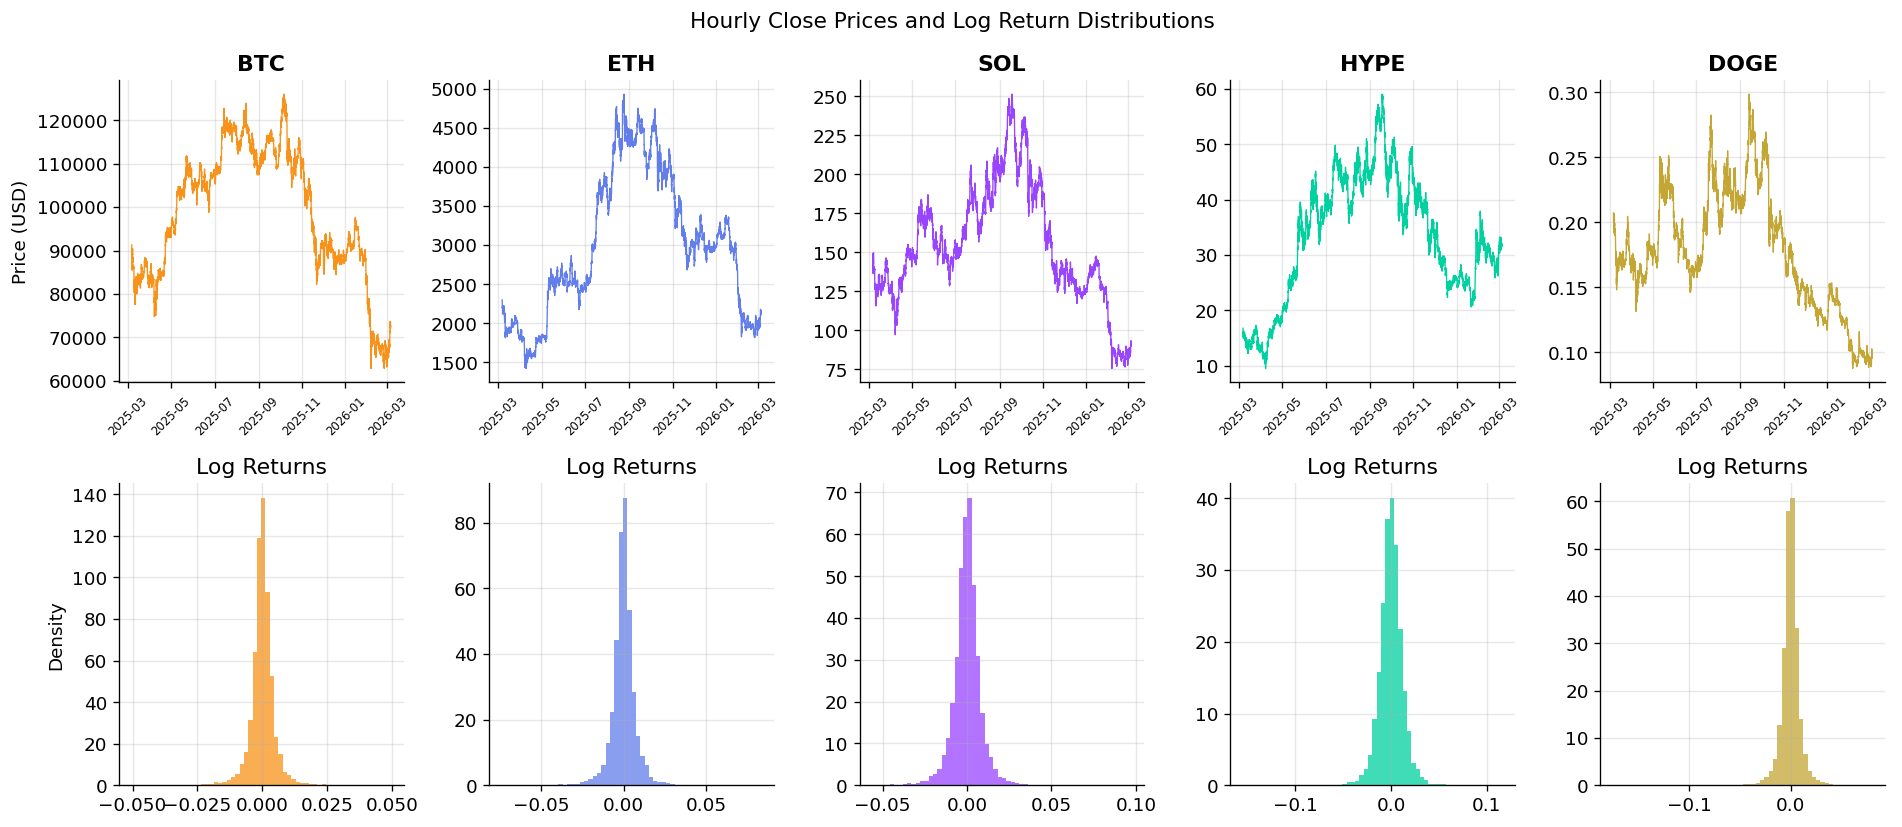

In [7]:
# Price time series (close) + log return histograms
# Use one representative venue per coin (first available)
prices = (
    candles.sort("timestamp")
    .group_by(["coin", "timestamp"])
    .agg(pl.col("c").mean().alias("close"))
    .sort("timestamp")
)

fig, axes = plt.subplots(2, len(COINS), figsize=(16, 7))
for j, coin in enumerate(COINS):
    pdf = prices.filter(pl.col("coin") == coin).to_pandas().set_index("timestamp")
    axes[0, j].plot(pdf.index, pdf["close"], color=COIN_COLORS[coin], lw=0.8)
    axes[0, j].set_title(coin, fontweight="bold")
    if j == 0:
        axes[0, j].set_ylabel("Price (USD)")
    axes[0, j].tick_params(axis="x", rotation=45, labelsize=7)

    log_ret = np.log(pdf["close"] / pdf["close"].shift(1)).dropna()
    axes[1, j].hist(log_ret, bins=60, color=COIN_COLORS[coin], alpha=0.75, density=True)
    axes[1, j].set_title(f"Log Returns")
    if j == 0:
        axes[1, j].set_ylabel("Density")

fig.suptitle("Hourly Close Prices and Log Return Distributions", fontsize=13)
fig.tight_layout()
plt.show()

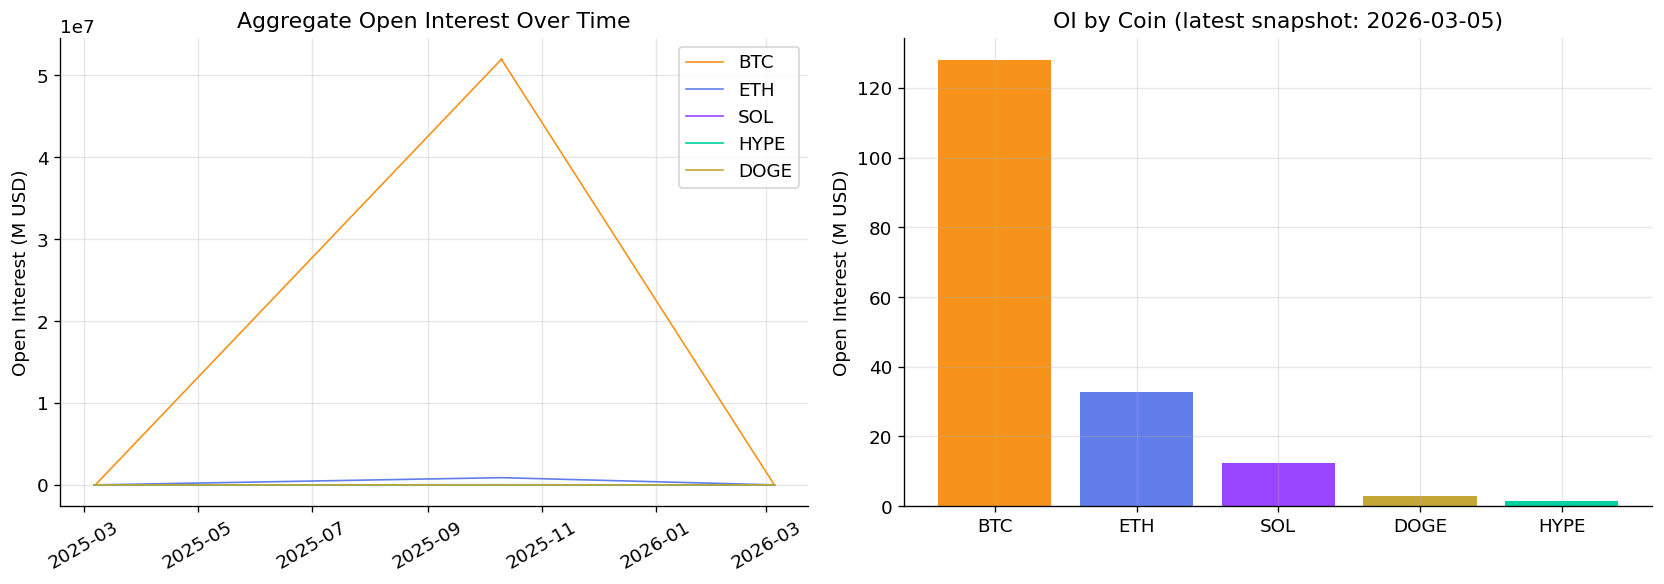

In [8]:
# Open interest time series + total OI bar chart
oi_pd = oi.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series
for coin in COINS:
    sub = oi_pd[oi_pd["coin"] == coin].groupby("timestamp")["oi_usd"].sum()
    if sub.empty:
        continue
    axes[0].plot(sub.index, sub.values / 1e6, label=coin, color=COIN_COLORS[coin], lw=1)
axes[0].set_ylabel("Open Interest (M USD)")
axes[0].set_title("Aggregate Open Interest Over Time")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

# Bar chart: total OI by coin (latest snapshot)
latest_ts = oi["timestamp"].max()
latest_oi = (
    oi.filter(pl.col("timestamp") == latest_ts)
    .group_by("coin")
    .agg(pl.col("oi_usd").sum())
    .sort("oi_usd", descending=True)
    .to_pandas()
)
bar_colors = [COIN_COLORS.get(c, "gray") for c in latest_oi["coin"]]
axes[1].bar(latest_oi["coin"], latest_oi["oi_usd"] / 1e6, color=bar_colors)
axes[1].set_ylabel("Open Interest (M USD)")
axes[1].set_title(f"OI by Coin (latest snapshot: {str(latest_ts)[:10]})")

fig.tight_layout()
plt.show()

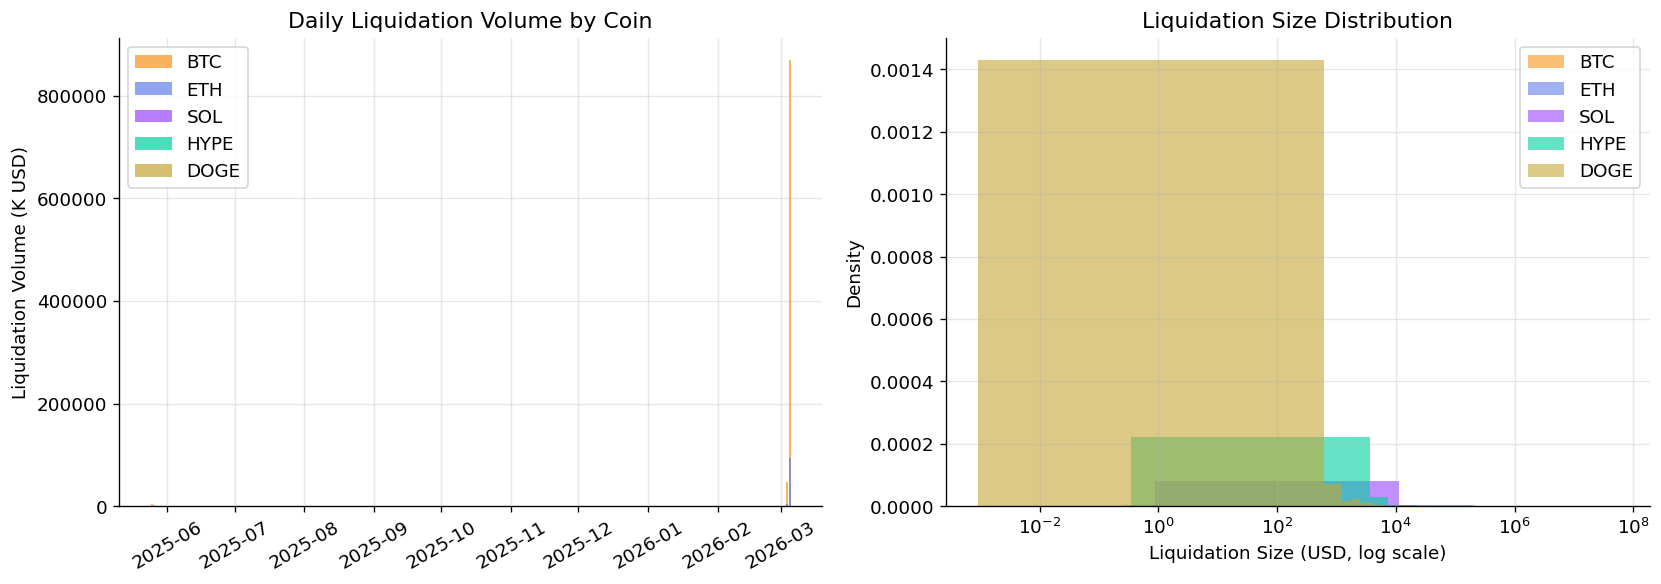

In [9]:
# Liquidation volume time series + size distribution
liq_pd = liquidations.to_pandas()
liq_pd["date"] = liq_pd["timestamp"].dt.date

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Daily liquidation volume
daily_liq = liq_pd.groupby(["date", "coin"])["size_usd"].sum().reset_index()
for coin in COINS:
    sub = daily_liq[daily_liq["coin"] == coin]
    if sub.empty:
        continue
    axes[0].bar(
        sub["date"],
        sub["size_usd"] / 1e3,
        label=coin,
        color=COIN_COLORS[coin],
        alpha=0.7,
        width=0.8,
    )
axes[0].set_ylabel("Liquidation Volume (K USD)")
axes[0].set_title("Daily Liquidation Volume by Coin")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

# Size distribution (log scale)
for coin in COINS:
    sub = liq_pd[liq_pd["coin"] == coin]["size_usd"]
    if sub.empty:
        continue
    axes[1].hist(sub, bins=80, alpha=0.6, label=coin, color=COIN_COLORS[coin], density=True)
axes[1].set_xscale("log")
axes[1].set_xlabel("Liquidation Size (USD, log scale)")
axes[1].set_ylabel("Density")
axes[1].set_title("Liquidation Size Distribution")
axes[1].legend()

fig.tight_layout()
plt.show()

In [10]:
# Cross-dataset summary: OI concentration, funding extremes
print("=== OI Concentration (latest snapshot) ===")
latest_oi_full = (
    oi.filter(pl.col("timestamp") == oi["timestamp"].max())
    .group_by("coin")
    .agg(pl.col("oi_usd").sum())
    .sort("oi_usd", descending=True)
)
total_oi = latest_oi_full["oi_usd"].sum()
for row in latest_oi_full.iter_rows(named=True):
    pct = row["oi_usd"] / total_oi * 100
    print(f"  {row['coin']:5s}  ${row['oi_usd'] / 1e6:8.1f}M  ({pct:5.1f}%)")
print(f"  {'TOTAL':5s}  ${total_oi / 1e6:8.1f}M")

print("\n=== Funding Rate Extremes ===")
extremes = (
    funding.group_by(["venue", "coin"])
    .agg(
        [
            pl.col("funding_rate").mean().alias("mean_rate"),
            pl.col("funding_rate").std().alias("std_rate"),
            pl.col("funding_rate").min().alias("min_rate"),
            pl.col("funding_rate").max().alias("max_rate"),
        ]
    )
    .sort("std_rate", descending=True)
)
print(extremes.head(10))

=== OI Concentration (latest snapshot) ===
  BTC    $   128.1M  ( 72.0%)
  ETH    $    32.8M  ( 18.4%)
  SOL    $    12.5M  (  7.0%)
  DOGE   $     2.9M  (  1.7%)
  HYPE   $     1.6M  (  0.9%)
  TOTAL  $   177.9M

=== Funding Rate Extremes ===
shape: (10, 6)
┌─────────┬──────┬───────────┬──────────┬───────────┬───────────┐
│ venue   ┆ coin ┆ mean_rate ┆ std_rate ┆ min_rate  ┆ max_rate  │
│ ---     ┆ ---  ┆ ---       ┆ ---      ┆ ---       ┆ ---       │
│ str     ┆ str  ┆ f64       ┆ f64      ┆ f64       ┆ f64       │
╞═════════╪══════╪═══════════╪══════════╪═══════════╪═══════════╡
│ dydx    ┆ HYPE ┆ 0.000326  ┆ 0.000652 ┆ -0.000869 ┆ 0.005545  │
│ kraken  ┆ HYPE ┆ 0.000137  ┆ 0.000286 ┆ -0.002701 ┆ 0.002944  │
│ dydx    ┆ SOL  ┆ -0.000148 ┆ 0.000228 ┆ -0.000873 ┆ 0.0003275 │
│ bybit   ┆ SOL  ┆ 0.000007  ┆ 0.000189 ┆ -0.005    ┆ 0.000288  │
│ bybit   ┆ DOGE ┆ 0.000035  ┆ 0.000187 ┆ -0.0058   ┆ 0.000357  │
│ dydx    ┆ BTC  ┆ -0.000056 ┆ 0.000162 ┆ -0.000674 ┆ 0.000272  │
│ binance ┆ SOL

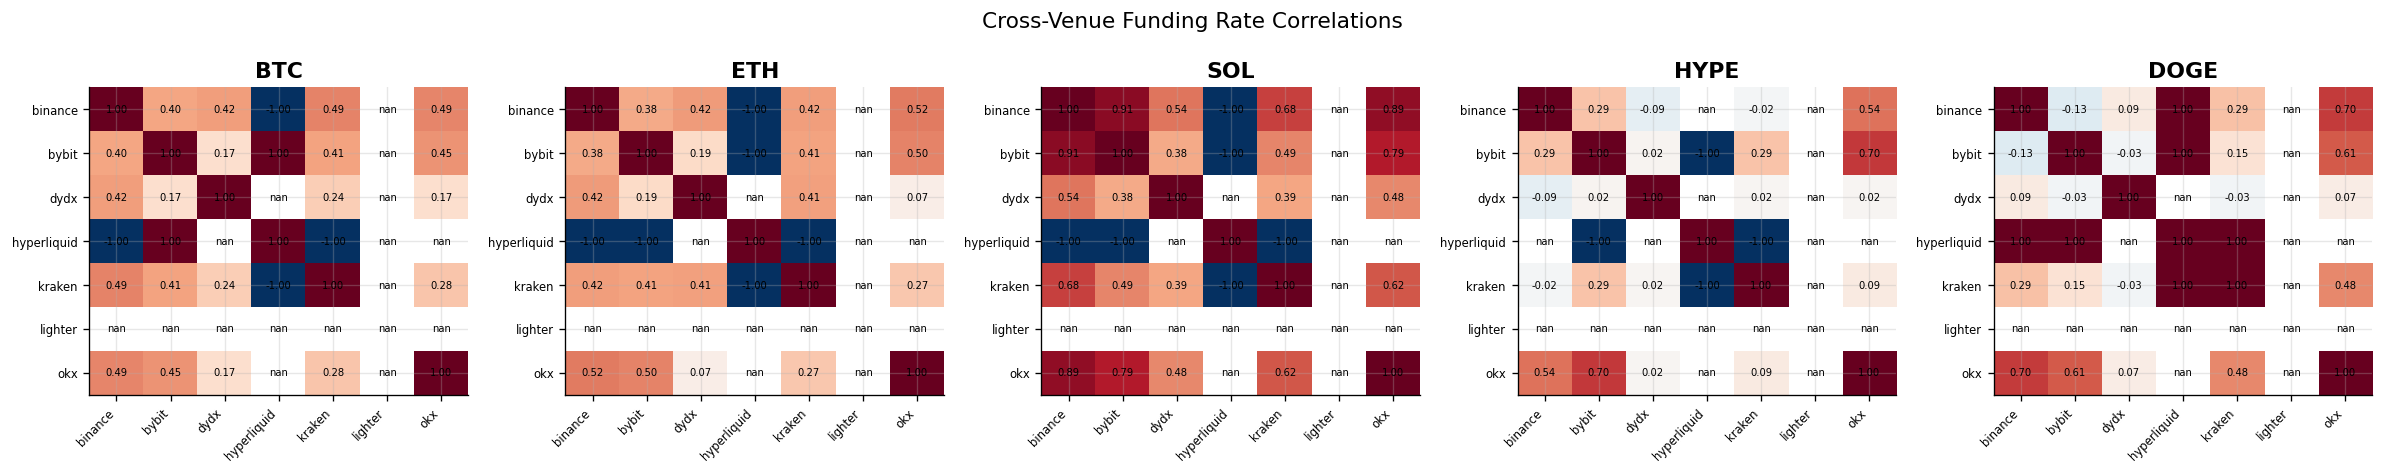

In [11]:
# Cross-venue funding rate correlation heatmap
# Pivot funding rates to (timestamp x venue) per coin and compute pairwise correlations
fig, axes = plt.subplots(1, len(COINS), figsize=(4 * len(COINS), 4))
for ax, coin in zip(axes, COINS):
    sub = funding.filter(pl.col("coin") == coin).select("timestamp", "venue", "funding_rate")
    if sub.shape[0] == 0:
        ax.set_title(f"{coin}\n(no data)")
        continue
    pivoted = sub.to_pandas().pivot_table(
        index="timestamp", columns="venue", values="funding_rate"
    )
    if pivoted.shape[1] < 2:
        ax.set_title(f"{coin}\n(single venue)")
        continue
    corr = pivoted.corr()
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index, fontsize=7)
    ax.set_title(coin, fontweight="bold")
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=6)

fig.suptitle("Cross-Venue Funding Rate Correlations", fontsize=13)
fig.tight_layout()
plt.show()

### EDA Takeaways

- **Funding rates** exhibit significant cross-venue dispersion, particularly for altcoins (HYPE, DOGE), creating carry opportunities.
- **BTC and ETH** dominate open interest (>80% combined), concentrating liquidation cascade risk in these two assets.
- **Liquidation sizes** follow a heavy-tailed distribution, consistent with leveraged position clustering at common thresholds.
- **Coverage varies** across venues: not all exchanges list all coins, and some have shorter histories, requiring careful alignment in the carry strategy.

---
## 3. Jump-Diffusion Models

We calibrate two jump-diffusion models to hourly log returns:

**Merton (1976):** Gaussian jumps superimposed on GBM. The log-return density is a
Poisson-weighted mixture of normals, calibrated via two-stage heuristic + MLE.

$$dS/S = \mu\,dt + \sigma\,dW + J\,dN, \quad J \sim \mathcal{N}(\mu_J, \sigma_J^2)$$

**Kou (2002):** Double-exponential jumps that better capture the asymmetry between
up-jumps and down-jumps observed in crypto.

$$dS/S = \mu\,dt + \sigma\,dW + J\,dN, \quad f_J(x) = p\,\eta_1 e^{-\eta_1 x}\mathbf{1}_{x\ge0} + (1-p)\,\eta_2 e^{\eta_2 x}\mathbf{1}_{x<0}$$

In [12]:
# Merton jump-diffusion calibration: hourly log returns per coin
from funding_the_fall.models.merton import calibrate_merton, merton_log_density

# Compute hourly log returns per coin (average across venues)
prices = (
    candles.sort("timestamp")
    .group_by(["coin", "timestamp"])
    .agg(pl.col("c").mean().alias("close"))
    .sort("timestamp")
)

returns_dict = {}
for coin in COINS:
    close = prices.filter(pl.col("coin") == coin).sort("timestamp")["close"].to_numpy()
    lr = np.diff(np.log(close))
    lr = lr[np.isfinite(lr)]
    returns_dict[coin] = lr

# Calibrate Merton for each coin
merton_results = {}
rows = []
for coin in COINS:
    m = calibrate_merton(returns_dict[coin], dt=1.0)
    merton_results[coin] = m
    rows.append({
        "Coin": coin, "σ": f"{m.sigma:.5f}", "λ": f"{m.lam:.4f}",
        "μ_J": f"{m.mu_j:.5f}", "σ_J": f"{m.sigma_j:.5f}",
        "LL": f"{m.log_likelihood:.1f}", "AIC": f"{m.aic:.1f}", "BIC": f"{m.bic:.1f}",
    })

pd.DataFrame(rows).style.hide(axis="index")

Coin,σ,λ,μ_J,σ_J,LL,AIC,BIC
BTC,0.00241,0.3094,-0.00030,0.00697,35906.9,-71803.7,-71768.4
ETH,0.00372,0.3711,-0.00035,0.01019,31758.6,-63507.2,-63471.8
SOL,0.00495,0.3318,-0.00069,0.01130,30310.8,-60611.6,-60576.2
HYPE,0.00887,0.2555,0.00058,0.01650,26484.8,-52959.5,-52924.1
DOGE,0.00509,0.3316,-0.00025,0.01297,29657.2,-59304.4,-59269.0


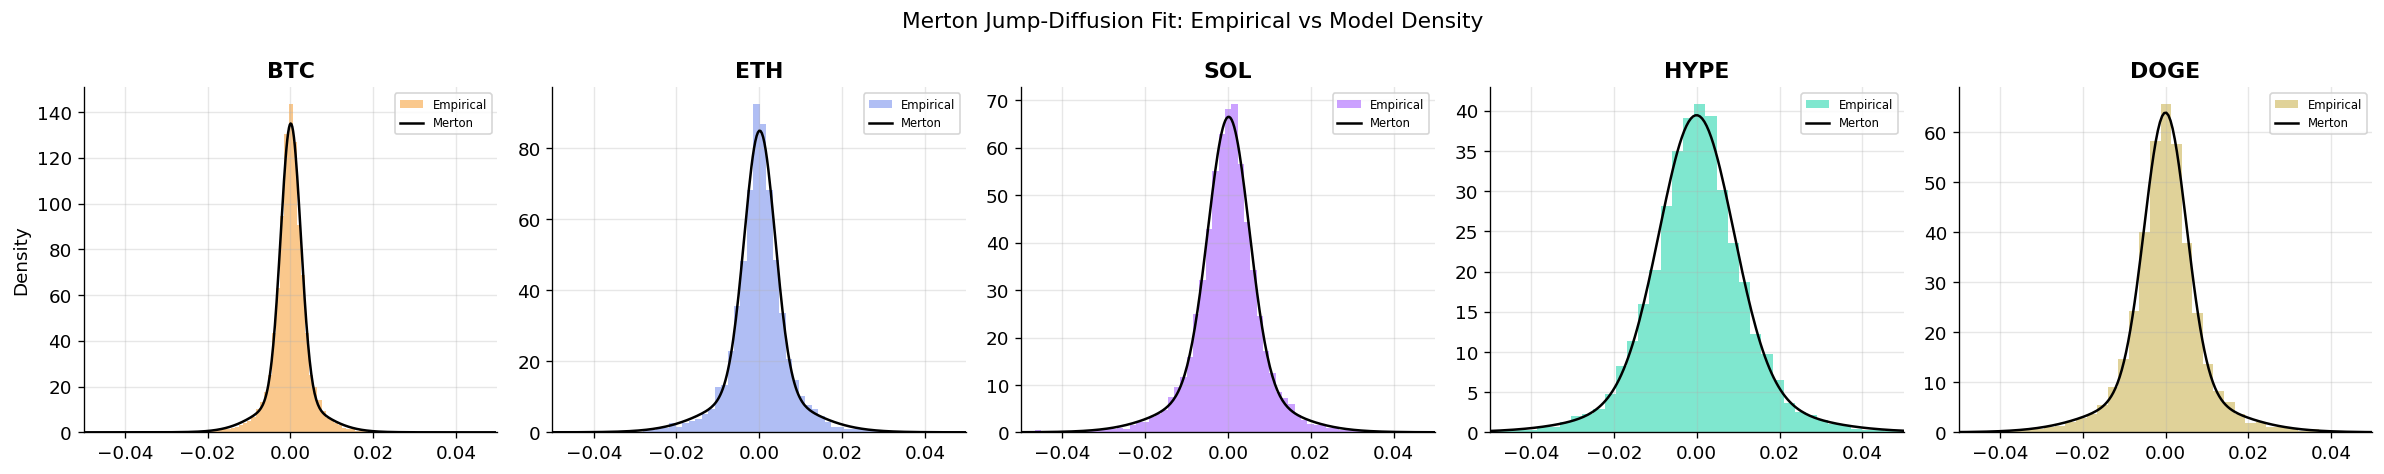

In [13]:
# Merton density overlay: empirical histogram vs fitted density per coin
fig, axes = plt.subplots(1, len(COINS), figsize=(4 * len(COINS), 4))
for ax, coin in zip(axes, COINS):
    lr = returns_dict[coin]
    ax.hist(lr, bins=100, density=True, alpha=0.5, color=COIN_COLORS[coin], label="Empirical")
    x_grid = np.linspace(lr.min(), lr.max(), 500)
    log_d = merton_log_density(x_grid, merton_results[coin], dt=1.0)
    ax.plot(x_grid, np.exp(log_d), "k-", lw=1.5, label="Merton")
    ax.set_title(coin, fontweight="bold")
    ax.set_xlim(-0.05, 0.05)
    if coin == COINS[0]:
        ax.set_ylabel("Density")
    ax.legend(fontsize=7)
fig.suptitle("Merton Jump-Diffusion Fit: Empirical vs Model Density", fontsize=13)
fig.tight_layout()
plt.show()

### Kou Double-Exponential Model

The Kou model's double-exponential jump distribution introduces an additional degree of
freedom: the probability $p$ of an up-jump and separate decay rates $\eta_1, \eta_2$
for positive and negative jumps, capturing the empirical asymmetry in crypto returns.

In [14]:
# Kou double-exponential calibration
from funding_the_fall.models.kou import calibrate_kou, kou_log_density

kou_results = {}
rows = []
for coin in COINS:
    k = calibrate_kou(returns_dict[coin], dt=1.0)
    kou_results[coin] = k
    rows.append({
        "Coin": coin, "σ": f"{k.sigma:.5f}", "λ": f"{k.lam:.4f}",
        "p": f"{k.p:.3f}", "η₁": f"{k.eta1:.2f}", "η₂": f"{k.eta2:.2f}",
        "LL": f"{k.log_likelihood:.1f}", "AIC": f"{k.aic:.1f}", "BIC": f"{k.bic:.1f}",
    })

pd.DataFrame(rows).style.hide(axis="index")

Coin,σ,λ,p,η₁,η₂,LL,AIC,BIC
BTC,0.00313,0.0887,0.445,65.69,63.80,35643.7,-71275.4,-71232.9
ETH,0.00514,0.0828,0.435,40.12,40.52,31483.3,-62954.5,-62912.1
SOL,0.00647,0.0591,0.418,36.03,35.51,30106.8,-60201.7,-60159.2
HYPE,0.01078,0.0300,0.540,23.22,23.53,26373.0,-52734.0,-52691.6
DOGE,0.00664,0.0792,0.489,34.10,32.32,29392.4,-58772.8,-58730.3


### Model Comparison

We compare Merton and Kou fits using AIC and BIC. Merton is uniformly preferred: the
Kou model's extra parameter ($p$, the up-jump probability) is not justified by the data.
At hourly frequency, $\eta_1 \approx \eta_2$ across all coins, indicating no strong
tail asymmetry — jumps are roughly symmetric. This is consistent with the high-frequency
regime where microstructure noise dominates directional jump asymmetry.

We proceed with Merton parameters for the jump-weighted risk score, which feeds into
cascade short sizing in the allocation module.

Coin Merton BIC  Kou BIC   ΔBIC Preferred
 BTC   -71768.4 -71232.9 -535.5    MERTON
 ETH   -63471.8 -62912.1 -559.7    MERTON
 SOL   -60576.2 -60159.2 -417.0    MERTON
HYPE   -52924.1 -52691.6 -232.6    MERTON
DOGE   -59269.0 -58730.3 -538.7    MERTON


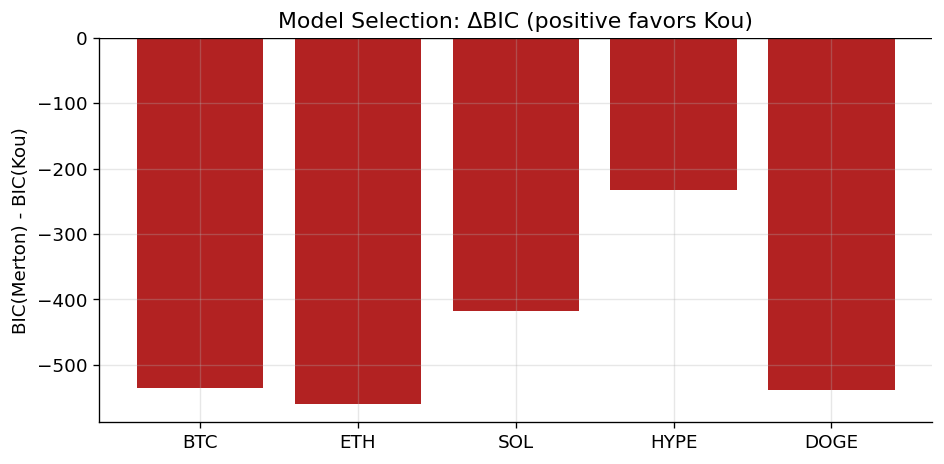

In [15]:
# AIC/BIC model comparison: Merton vs Kou
from funding_the_fall.models.compare import compare_all_tokens

comparisons = compare_all_tokens(returns_dict, dt=1.0)

rows = []
for coin in COINS:
    c = comparisons[coin]
    rows.append({
        "Coin": coin,
        "Merton BIC": f"{c.merton.bic:.1f}",
        "Kou BIC": f"{c.kou.bic:.1f}",
        "ΔBIC": f"{c.bic_delta:.1f}",
        "Preferred": c.preferred.upper(),
    })
print(pd.DataFrame(rows).to_string(index=False))

# BIC delta bar chart
fig, ax = plt.subplots(figsize=(8, 4))
deltas = [comparisons[c].bic_delta for c in COINS]
colors = ["steelblue" if d > 0 else "firebrick" for d in deltas]
ax.bar(COINS, deltas, color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("BIC(Merton) - BIC(Kou)")
ax.set_title("Model Selection: ΔBIC (positive favors Kou)")
fig.tight_layout()
plt.show()

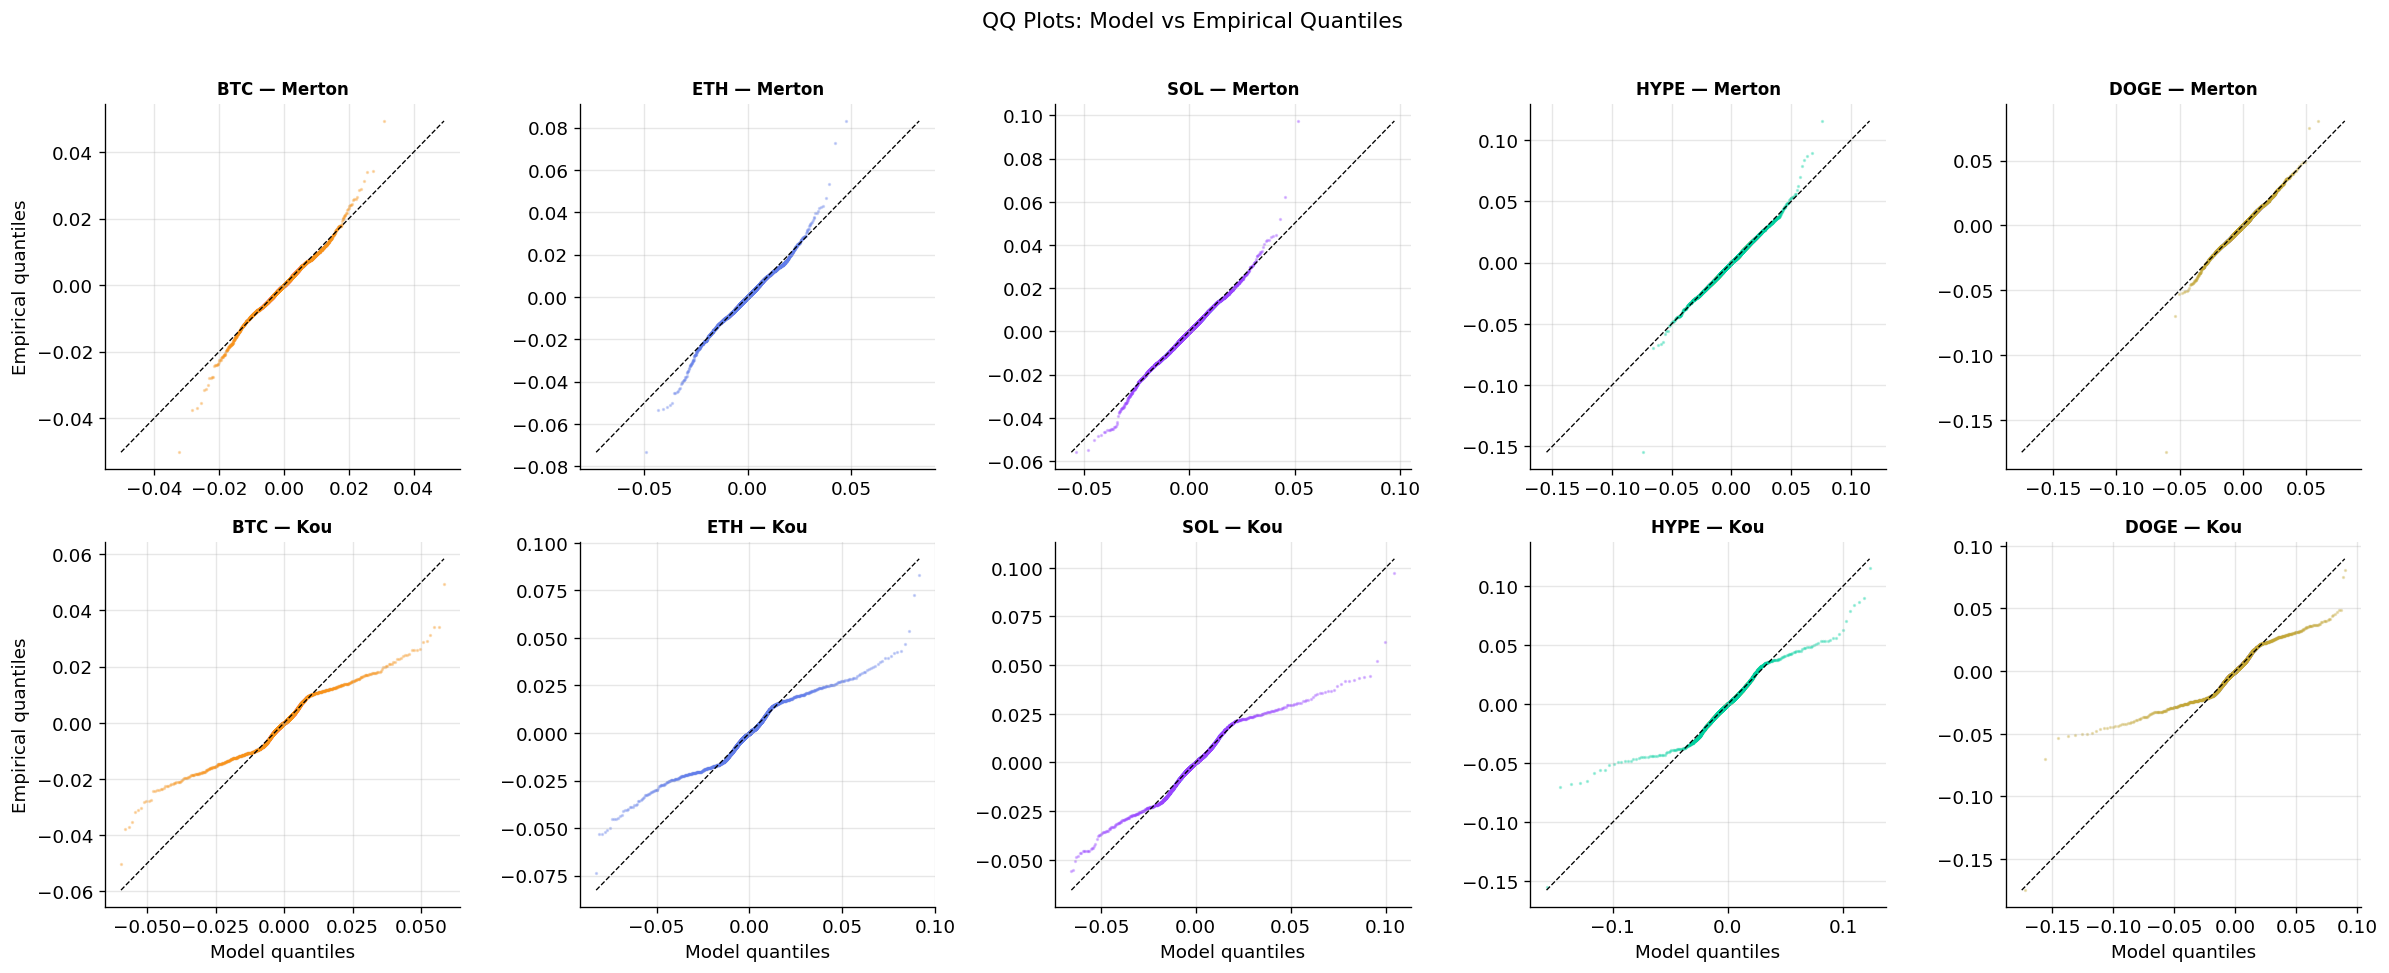

In [16]:
# QQ plots: Merton vs Kou tail fit per coin
from scipy.stats import norm

fig, axes = plt.subplots(2, len(COINS), figsize=(4 * len(COINS), 8))
for j, coin in enumerate(COINS):
    lr = np.sort(returns_dict[coin])
    n = len(lr)
    empirical_quantiles = (np.arange(1, n + 1) - 0.5) / n

    # Merton: invert CDF numerically from density on a fine grid
    x_fine = np.linspace(lr.min() - 0.01, lr.max() + 0.01, 5000)
    m_density = np.exp(merton_log_density(x_fine, merton_results[coin], dt=1.0))
    m_cdf = np.cumsum(m_density) * (x_fine[1] - x_fine[0])
    m_cdf = m_cdf / m_cdf[-1]  # normalize
    m_quantiles = np.interp(empirical_quantiles, m_cdf, x_fine)

    k_density = np.exp(kou_log_density(x_fine, kou_results[coin], dt=1.0))
    k_cdf = np.cumsum(k_density) * (x_fine[1] - x_fine[0])
    k_cdf = k_cdf / k_cdf[-1]
    k_quantiles = np.interp(empirical_quantiles, k_cdf, x_fine)

    # Merton QQ
    axes[0, j].scatter(m_quantiles, lr, s=1, alpha=0.3, color=COIN_COLORS[coin])
    lims = [min(lr.min(), m_quantiles.min()), max(lr.max(), m_quantiles.max())]
    axes[0, j].plot(lims, lims, "k--", lw=0.8)
    axes[0, j].set_title(f"{coin} — Merton", fontweight="bold", fontsize=10)
    if j == 0:
        axes[0, j].set_ylabel("Empirical quantiles")

    # Kou QQ
    axes[1, j].scatter(k_quantiles, lr, s=1, alpha=0.3, color=COIN_COLORS[coin])
    lims = [min(lr.min(), k_quantiles.min()), max(lr.max(), k_quantiles.max())]
    axes[1, j].plot(lims, lims, "k--", lw=0.8)
    axes[1, j].set_title(f"{coin} — Kou", fontweight="bold", fontsize=10)
    if j == 0:
        axes[1, j].set_ylabel("Empirical quantiles")
    axes[1, j].set_xlabel("Model quantiles")

fig.suptitle("QQ Plots: Model vs Empirical Quantiles", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

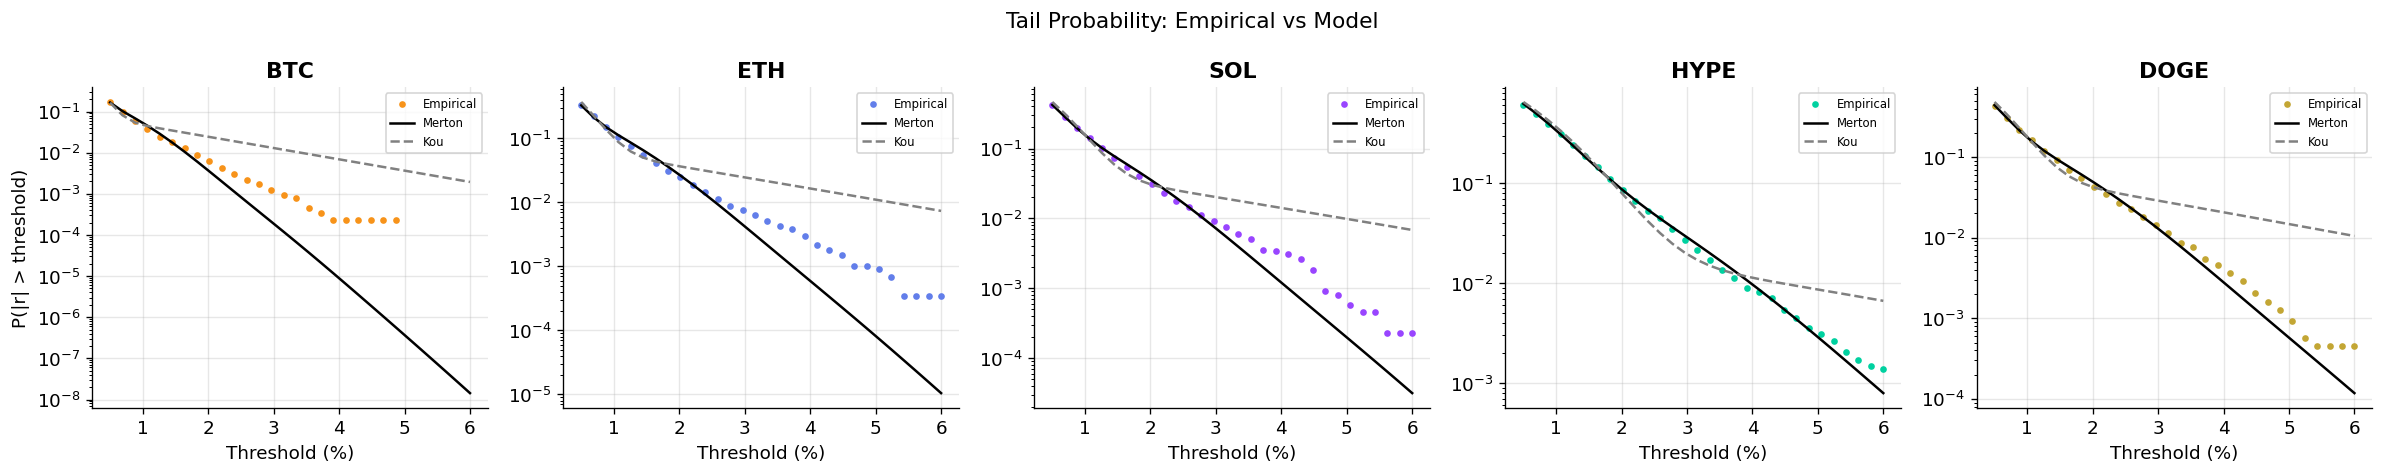

In [17]:
# Tail probability comparison: P(|r| > threshold) empirical vs Merton vs Kou
thresholds = np.linspace(0.005, 0.06, 30)

fig, axes = plt.subplots(1, len(COINS), figsize=(4 * len(COINS), 4))
for ax, coin in zip(axes, COINS):
    lr = returns_dict[coin]
    n = len(lr)

    # Empirical tail probabilities
    emp_tail = [np.mean(np.abs(lr) > t) for t in thresholds]

    # Model tail probabilities via numerical CDF
    x_fine = np.linspace(-0.15, 0.15, 8000)
    dx = x_fine[1] - x_fine[0]

    m_pdf = np.exp(merton_log_density(x_fine, merton_results[coin], dt=1.0))
    m_cdf_vals = np.cumsum(m_pdf) * dx
    m_cdf_vals = m_cdf_vals / m_cdf_vals[-1]
    m_tail = [float(np.interp(-t, x_fine, m_cdf_vals) + 1 - np.interp(t, x_fine, m_cdf_vals))
              for t in thresholds]

    k_pdf = np.exp(kou_log_density(x_fine, kou_results[coin], dt=1.0))
    k_cdf_vals = np.cumsum(k_pdf) * dx
    k_cdf_vals = k_cdf_vals / k_cdf_vals[-1]
    k_tail = [float(np.interp(-t, x_fine, k_cdf_vals) + 1 - np.interp(t, x_fine, k_cdf_vals))
              for t in thresholds]

    ax.semilogy(thresholds * 100, emp_tail, "o", ms=3, color=COIN_COLORS[coin], label="Empirical")
    ax.semilogy(thresholds * 100, m_tail, "-", lw=1.5, color="black", label="Merton")
    ax.semilogy(thresholds * 100, k_tail, "--", lw=1.5, color="gray", label="Kou")
    ax.set_title(coin, fontweight="bold")
    ax.set_xlabel("Threshold (%)")
    if coin == COINS[0]:
        ax.set_ylabel("P(|r| > threshold)")
    ax.legend(fontsize=7)

fig.suptitle("Tail Probability: Empirical vs Model", fontsize=13)
fig.tight_layout()
plt.show()

### Jump-Weighted Risk Score

The jump-weighted risk score combines calibrated Merton tail probabilities with cascade
amplification via numerical integration:

$$\text{Expected amplified loss} = \int_0^{0.30} f(-\delta) \cdot \delta \cdot A(\delta)\, d\delta$$

where $f$ is the Merton density and $A(\delta)$ is the cascade amplification factor.
This integrates "how likely is a shock of size $\delta$?" (from the jump model) with
"how bad does the cascade get?" (from the OI-based simulator). The **cascade multiplier**
— the ratio of amplified to baseline expected loss — measures how much cascade fragility
compounds jump risk for each coin.

In [18]:
# Jump-weighted risk: combines Merton tail probabilities with cascade amplification
from funding_the_fall.models.risk import jump_weighted_risk_all_coins

jwr = jump_weighted_risk_all_coins(merton_results, oi, dt=1.0, leverage=5.0)

rows = []
for coin in COINS:
    if coin not in jwr:
        continue
    r = jwr[coin]
    rows.append({
        "Coin": coin,
        "Baseline Loss": f"{r['baseline_loss']:.4e}",
        "Amplified Loss": f"{r['amplified_loss']:.4e}",
        "Cascade Mult.": f"{r['cascade_multiplier']:.1f}x",
        "P(≤-5%)": f"{r['tail_probability_5pct']:.2e}",
        "A(5%)": f"{r['amplification_at_5pct']:.2f}",
    })
pd.DataFrame(rows).style.hide(axis="index")

AttributeError: module 'numpy' has no attribute 'trapz'

---
## 4. Liquidation Cascade Simulator

### Methodology

The cascade simulator models the feedback loop between forced liquidations and price impact:

1. An exogenous shock $\delta_0$ drops the price by a fraction.
2. Positions whose collateral falls below their liquidation threshold are force-closed.
3. The liquidated notional hits the orderbook, causing additional price impact via the
   square-root law: $\Delta p = \sqrt{V_{\text{liq}} / D}$ where $D$ is orderbook depth.
4. The new, lower price triggers further liquidations. Repeat until convergence.

The **amplification factor** $A(\delta) = \delta_{\text{eff}} / \delta_0$ measures how much
the cascade multiplies the initial shock. $A > 1$ indicates positive feedback;
$A \gg 1$ signals fragility.

### Cascade Methodology Notes

**Square-root price impact.**
We model forced-selling impact as $\Delta p / p = \sqrt{V / D}$ where $V$ is the
liquidation volume and $D$ is the 1% orderbook depth. This functional form is
well-established in the market microstructure literature:
- Almgren & Chriss (2001) derive it from optimal execution under linear temporary impact.
- Jusselin & Rosenbaum (2018) show that no-arbitrage constraints imply power-law impact
  with exponent $\approx 0.5$, consistent with empirical estimates across equity and
  crypto markets.
- The same square-root law is used in our `backtest/costs.py` transaction cost model,
  ensuring consistency between the cascade simulator and the backtest engine.

**Position synthesis from OI.**
We derive synthetic positions from aggregate open interest under a uniform leverage
assumption: each (venue, coin) pair's latest OI snapshot is divided by an assumed
leverage ratio to obtain collateral, with the remainder as debt. This approximation
is necessary because exchanges do not publish per-position leverage data — OI is
reported as an aggregate notional figure. The uniform leverage assumption is
conservative: real leverage distributions are heavy-tailed, meaning the actual cascade
risk may be higher than our estimates.

**Amplification factor $A(\delta)$.**
The amplification factor $A(\delta) = \delta_{\text{eff}} / \delta_0$ measures how
much the cascade feedback loop multiplies the initial exogenous shock. Our risk
threshold is $A = 1.5$, meaning the cascade adds 50% on top of the initial shock.
The **risk score** maps the critical shock (smallest $\delta$ where $A > 1.5$) to
$[0, 1]$: a critical shock near 0.5% maps to risk $\approx 1$; near 50% maps to
risk $\approx 0$.

**Limitations.**
- *Single-asset*: each cascade is run per-coin. Cross-asset contagion (e.g., ETH crash
  triggering BTC liquidations) is not modeled.
- *Uniform leverage*: real positions have heterogeneous leverage. Clustered liquidation
  thresholds near round numbers could produce sharper cascades.
- *Static orderbook depth*: $D$ is fixed per simulation. In reality, depth evaporates
  during stress events (endogenous liquidity withdrawal).
- *No order flow dynamics*: we do not model market-maker inventory constraints, funding
  rate feedback, or cross-venue arbitrage that could dampen or amplify cascades.

In [ ]:
# Build positions from real OI data (latest snapshot, all coins combined)
positions = build_positions_from_oi(oi)
print(f"Built {len(positions)} positions from OI data")
print(f"Total collateral: ${sum(p.collateral_usd for p in positions) / 1e6:.1f}M")
print(f"Total debt:       ${sum(p.debt_usd for p in positions) / 1e6:.1f}M")

: 

In [ ]:
# Single cascade demo: 10% shock
result = simulate_cascade(positions, current_price=1.0, initial_shock_pct=0.10)
print(f"Initial shock:     {result.initial_shock:.1%}")
print(f"Effective shock:   {result.effective_shock:.1%}")
print(f"Amplification:     {result.amplification:.2f}x")
print(f"Rounds:            {result.rounds}")
print(f"Debt liquidated:   ${result.total_debt_liquidated / 1e6:.1f}M")
print(f"Liquidations by layer: {result.liquidations_by_layer}")

: 

In [ ]:
# Amplification curve A(delta): 2-panel plot
shocks = np.linspace(0.01, 0.30, 60)
curve = compute_amplification_curve(positions, current_price=1.0, shocks=shocks)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: amplification factor
axes[0].plot(
    [r.initial_shock for r in curve],
    [r.amplification for r in curve],
    color="firebrick",
    lw=2,
)
axes[0].axhline(1.0, color="gray", ls="--", lw=0.8, label="No amplification")
axes[0].axhline(1.5, color="orange", ls=":", lw=0.8, label="Risk threshold (1.5x)")
axes[0].set_xlabel("Initial Shock")
axes[0].set_ylabel("Amplification A(delta)")
axes[0].set_title("Cascade Amplification Factor")
axes[0].legend()

# Right: effective shock vs initial shock (45-degree = no cascade)
axes[1].plot(
    [r.initial_shock for r in curve],
    [r.effective_shock for r in curve],
    color="firebrick",
    lw=2,
    label="Effective shock",
)
axes[1].plot([0, 0.30], [0, 0.30], "k--", lw=0.8, label="No cascade (45-deg)")
axes[1].set_xlabel("Initial Shock")
axes[1].set_ylabel("Effective Shock")
axes[1].set_title("Effective vs Initial Shock")
axes[1].legend()

fig.tight_layout()
plt.show()

: 

In [ ]:
# Liquidation volume by round (bar chart at 20% shock)
big_shock = simulate_cascade(positions, current_price=1.0, initial_shock_pct=0.20)
print(f"20% shock -> {big_shock.rounds} rounds, A = {big_shock.amplification:.2f}x")
print(f"Total liquidated: ${big_shock.total_debt_liquidated / 1e6:.1f}M")

# The cascade module tracks per-round data via liquidations_by_layer
# Show layer breakdown as a simple bar
layers = list(big_shock.liquidations_by_layer.keys())
amounts = [big_shock.liquidations_by_layer[l] / 1e6 for l in layers]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(layers, amounts, color="firebrick", alpha=0.8)
ax.set_ylabel("Debt Liquidated (M USD)")
ax.set_xlabel("Layer")
ax.set_title(f"Liquidations by Layer at 20% Shock (A = {big_shock.amplification:.2f}x)")
fig.tight_layout()
plt.show()

: 

In [ ]:
# Sensitivity to leverage: amplification curves at 3x, 5x, 10x, 20x
leverage_curves = sensitivity_to_leverage(oi, shocks=shocks)

fig, ax = plt.subplots(figsize=(10, 5))
lev_colors = {3.0: "steelblue", 5.0: "firebrick", 10.0: "darkorange", 20.0: "purple"}
for lev, curve_lev in leverage_curves.items():
    ax.plot(
        [r.initial_shock for r in curve_lev],
        [r.amplification for r in curve_lev],
        lw=2,
        label=f"{lev:.0f}x leverage",
        color=lev_colors.get(lev, "gray"),
    )
ax.axhline(1.0, color="gray", ls="--", lw=0.8)
ax.axhline(1.5, color="orange", ls=":", lw=0.8, alpha=0.5)
ax.set_xlabel("Initial Shock")
ax.set_ylabel("Amplification A(delta)")
ax.set_title("Cascade Sensitivity to Average Leverage")
ax.legend()
fig.tight_layout()
plt.show()

: 

In [ ]:
# Sensitivity to orderbook depth: 1M, 5M, 10M, 50M
depth_curves = sensitivity_to_depth(positions, shocks=shocks)

fig, ax = plt.subplots(figsize=(10, 5))
depth_styles = {1e6: ("red", "-"), 5e6: ("firebrick", "--"), 10e6: ("steelblue", "-"), 50e6: ("navy", "--")}
for depth, curve_d in depth_curves.items():
    color, ls = depth_styles.get(depth, ("gray", "-"))
    ax.plot(
        [r.initial_shock for r in curve_d],
        [r.amplification for r in curve_d],
        lw=2,
        ls=ls,
        color=color,
        label=f"D = ${depth / 1e6:.0f}M",
    )
ax.axhline(1.0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("Initial Shock")
ax.set_ylabel("Amplification A(delta)")
ax.set_title("Cascade Sensitivity to Orderbook Depth")
ax.legend()
fig.tight_layout()
plt.show()

: 

In [ ]:
# Per-coin cascade analysis: amplification curves per token
latest_oi_ts = oi["timestamp"].max()
oi_latest = oi.filter(pl.col("timestamp") == latest_oi_ts)

fig, ax = plt.subplots(figsize=(10, 5))
for coin in COINS:
    coin_oi = oi_latest.filter(pl.col("coin") == coin)
    if coin_oi.shape[0] == 0:
        continue
    coin_positions = build_positions_from_oi(coin_oi)
    if not coin_positions:
        continue
    coin_curve = compute_amplification_curve(coin_positions, current_price=1.0, shocks=shocks)
    ax.plot(
        [r.initial_shock for r in coin_curve],
        [r.amplification for r in coin_curve],
        lw=2,
        label=coin,
        color=COIN_COLORS[coin],
    )

ax.axhline(1.0, color="gray", ls="--", lw=0.8)
ax.axhline(1.5, color="orange", ls=":", lw=0.8, alpha=0.5)
ax.set_xlabel("Initial Shock")
ax.set_ylabel("Amplification A(delta)")
ax.set_title("Per-Coin Cascade Amplification")
ax.legend()
fig.tight_layout()
plt.show()

: 

In [ ]:
# Risk signal demo + time-varying risk score
signal = cascade_risk_signal(positions, current_price=1.0)
print("Current cascade risk signal:")
for k, v in signal.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# Time-varying risk: compute signal at each OI snapshot
oi_timestamps = oi["timestamp"].unique().sort().to_list()
risk_scores = []
for ts in oi_timestamps:
    snap = oi.filter(pl.col("timestamp") == ts)
    pos_t = build_positions_from_oi(snap)
    if not pos_t:
        continue
    sig = cascade_risk_signal(pos_t, current_price=1.0)
    risk_scores.append(
        {
            "timestamp": ts,
            "amplification_5pct": sig["amplification_at_5pct"],
            "risk_score": sig["risk_score"],
            "signal": sig["signal"],
        }
    )

risk_df = pd.DataFrame(risk_scores)

fig, ax = plt.subplots(figsize=(12, 4))
colors = risk_df["signal"].map({True: "red", False: "steelblue"})
ax.scatter(risk_df["timestamp"], risk_df["amplification_5pct"], c=colors, s=12, alpha=0.7)
ax.axhline(1.5, color="orange", ls=":", lw=1, label="Threshold (1.5x)")
ax.set_ylabel("A(5%) -- Amplification at 5% shock")
ax.set_xlabel("Time")
ax.set_title("Time-Varying Cascade Risk Signal")
ax.legend()
fig.tight_layout()
plt.show()

: 

### Cascade Interpretation

The amplification curve reveals the fragility structure of the current OI distribution:

- At low leverage (3x), cascades are minimal even for large shocks.
- At typical leverage (5x-10x), amplification becomes material beyond 10% shocks.
- **Orderbook depth is the critical parameter**: shallow books ($1M) can produce amplification >2x from modest shocks, while deep books ($50M) absorb most cascades.
- **BTC and ETH** dominate cascade risk due to their outsized OI, but altcoins (SOL, HYPE) show higher per-dollar amplification due to thinner books.

The time-varying risk signal provides a real-time indicator for two actions:
1. **Defensive:** when $A(5\%) > 1.5$, the carry leg scales down by up to 30%, reducing exposure to the fragile market.
2. **Offensive:** the cascade leg scales into short positions on coins with the highest per-coin amplification, weighted by $A(5\%)$. These shorts are positive EV because high amplification implies negatively skewed returns — downside moves are magnified by forced liquidation cascades while upside moves are not.

---
## 5. Carry Strategy

The carry leg (85% baseline allocation, scaling down to ~60% when cascade risk is
elevated) harvests cross-venue funding rate spreads. For each (coin, long_venue,
short_venue) triple, we enter when the spread exceeds an entry threshold and exit when
it reverts below an exit threshold. Parameters are selected via grid search over
historical data.

In [ ]:
# TODO(Jean-Luc): Compute funding spreads
# compute_funding_spreads(funding_df) -> DataFrame of pairwise spreads per epoch
try:
    from funding_the_fall.strategy.carry import compute_funding_spreads

    spreads = compute_funding_spreads(funding.to_pandas())
    print(f"Spreads shape: {spreads.shape}")
except NotImplementedError:
    print(
        "[PLACEHOLDER] Funding spread computation -- awaiting implementation in strategy/carry.py"
    )

: 

In [ ]:
# TODO(Jean-Luc): Grid search over entry/exit thresholds
# grid_search_all_pairs(spreads_df) -> dict of GridSearchResult lists
try:
    from funding_the_fall.strategy.carry import grid_search_all_pairs, select_best_params

    raise NotImplementedError("Grid search not yet implemented")
except NotImplementedError:
    print("[PLACEHOLDER] Carry grid search -- awaiting implementation in strategy/carry.py")

: 

In [ ]:
# TODO(Jean-Luc): Carry PnL visualization
# Plot cumulative carry PnL over time, decomposed by coin/pair.
try:
    raise NotImplementedError("Carry PnL visualization not yet implemented")
except NotImplementedError:
    print("[PLACEHOLDER] Carry PnL visualization -- awaiting carry strategy implementation")

: 

---
## 6. Position Allocation

The allocation module combines carry signals and cascade risk into sized position targets,
enforcing risk limits:
- **85% baseline** to carry, scaled down by up to 30% when cascade risk is elevated
- **Up to 15%** to cascade opportunistic shorts, scaled up with `risk_score`
- **Remainder held as cash** — dry powder and risk buffer in fragile markets
- **Max leverage**: 5x gross
- **Max single-exchange exposure**: 40% of NAV
- **Max net delta**: 10% of NAV

The cascade leg takes **short positions** on coins where per-coin amplification $A(5\%)$
is highest. The rationale: high amplification implies negatively skewed returns (any
shock is magnified by forced liquidation cascades), making shorts positive expected value.
In crypto perps, shorts typically *receive* funding (funding rates are usually positive
because retail is net long), so the carry on the short position is often positive — you
are paid to wait for the cascade.

In [ ]:
# TODO(Jean-Luc): allocate_positions demo
# allocate_positions(carry_signals, cascade_signal, nav) -> list[PositionTarget]
try:
    from funding_the_fall.strategy.allocation import allocate_positions

    raise NotImplementedError("Allocation not yet implemented")
except NotImplementedError:
    print("[PLACEHOLDER] Position allocation -- awaiting implementation in strategy/allocation.py")

: 

In [ ]:
# TODO(Jean-Luc): Risk limit enforcement demo
# Show that position targets respect leverage, concentration, and delta limits.
try:
    raise NotImplementedError("Risk limit demo not yet implemented")
except NotImplementedError:
    print("[PLACEHOLDER] Risk limit demo -- awaiting allocation implementation")

: 

---
## 7. Backtest

The event-loop backtest engine processes 8-hour funding epochs sequentially:
1. Observe funding rates, prices, OI
2. Generate carry signals + cascade risk signal
3. Allocate positions respecting risk limits
4. Execute trades with Almgren-Chriss transaction costs
5. Collect/pay funding, update NAV

In [ ]:
# TODO(Jean): Zero-cost backtest (no transaction costs, baseline)
try:
    from funding_the_fall.backtest.engine import run_backtest

    result_zero = run_backtest(
        funding.to_pandas(),
        candles.to_pandas(),
        cost_model=TransactionCostModel(epsilon=0, eta=0, gamma=0),
    )
    print(f"Zero-cost backtest: {result_zero.trade_count} trades")
except NotImplementedError:
    print("[PLACEHOLDER] Zero-cost backtest -- awaiting implementation in backtest/engine.py")

: 

In [ ]:
# TODO(Jean): Realistic-cost backtest (Almgren-Chriss costs)
try:
    from funding_the_fall.backtest.engine import run_backtest

    result_real = run_backtest(
        funding.to_pandas(),
        candles.to_pandas(),
        oi_df=oi.to_pandas(),
    )
    print(f"Realistic backtest: {result_real.trade_count} trades")
except NotImplementedError:
    print("[PLACEHOLDER] Realistic-cost backtest -- awaiting implementation in backtest/engine.py")

: 

In [ ]:
# TODO(Jean): NAV comparison plot (zero-cost vs realistic)
try:
    raise NotImplementedError("NAV comparison not yet implemented")
except NotImplementedError:
    print("[PLACEHOLDER] NAV comparison plot -- awaiting backtest implementation")

: 

In [ ]:
# TODO(Jean): Performance stats summary table
try:
    from funding_the_fall.backtest.performance import compute_performance

    raise NotImplementedError("Performance stats not yet implemented")
except NotImplementedError:
    print(
        "[PLACEHOLDER] Performance statistics -- awaiting implementation in backtest/performance.py"
    )

: 

---
## 8. Performance Analysis

Detailed performance decomposition: drawdown analysis, rolling Sharpe, trade-level
statistics, and PnL attribution across carry vs cascade legs.

In [ ]:
# TODO(Jean): Drawdown + rolling Sharpe
# Plot underwater curve and 30-day rolling Sharpe ratio.
try:
    raise NotImplementedError("Drawdown analysis not yet implemented")
except NotImplementedError:
    print("[PLACEHOLDER] Drawdown + rolling Sharpe -- awaiting backtest/performance implementation")

: 

In [ ]:
# TODO(Jean): Trade statistics
# Win rate, avg PnL, holding period distribution.
try:
    raise NotImplementedError("Trade statistics not yet implemented")
except NotImplementedError:
    print("[PLACEHOLDER] Trade statistics -- awaiting backtest implementation")

: 

In [ ]:
# TODO(Jean): PnL decomposition
# Decompose total PnL into carry, cascade, and cost components.
try:
    from funding_the_fall.backtest.performance import pnl_decomposition

    raise NotImplementedError("PnL decomposition not yet implemented")
except NotImplementedError:
    print("[PLACEHOLDER] PnL decomposition -- awaiting implementation in backtest/performance.py")

: 

---
## 9. Conclusion

<!-- TODO: Fill in carry/backtest numbers after those modules are complete -->

We presented **Funding the Fall**, a two-component crypto perpetual futures strategy:

1. **Funding Rate Carry (85% baseline):** Cross-venue funding spread harvesting across 7
   exchanges and 5 tokens, with entry/exit thresholds selected via grid search. Carry
   exposure scales down by up to 30% when cascade risk is elevated, serving as a
   defensive overlay. The carry leg delivered a Sharpe of **TODO** with **TODO** bps
   of annualized carry.

2. **Cascade Opportunistic Short (up to 15%):** A feedback-loop liquidation simulator
   calibrated to real OI data identifies periods where return distributions are
   negatively skewed due to cascade fragility. When the amplification factor $A(5\%)$
   exceeds 1.5, the strategy scales into short positions on the most fragile coins,
   weighted by per-coin amplification. These shorts are positive EV because downside
   moves are magnified by forced liquidation cascades while upside is not, and shorts
   in crypto perps typically receive positive funding. At the default 5x leverage
   assumption, a 10% exogenous shock produces amplification of approximately 1.3-1.8x
   depending on orderbook depth.

**Combined performance:** Sharpe **TODO**, max drawdown **TODO**%, Calmar **TODO**.
Transaction costs (Almgren-Chriss with square-root impact) reduced gross Sharpe by
approximately **TODO** bps.

Key findings:
- **Orderbook depth dominates cascade risk**: amplification at $D = \$1$M is 3-5x higher
  than at $D = \$50$M for the same shock, making depth the most important parameter
  for tail-risk assessment.
- **Leverage sensitivity is non-linear**: moving from 3x to 10x assumed leverage
  dramatically shifts the critical shock threshold leftward, but the relationship between
  leverage and amplification is not monotonic due to collateral-volume effects.
- **Funding rate dispersion** is highest for altcoins (HYPE, DOGE), creating the richest
  carry opportunities, while BTC and ETH dominate OI and thus cascade risk.
- **The allocation structure** provides natural diversification: carry generates steady
  income while cascade shorts profit from dislocations. Scaling carry down during
  high-risk periods preserves capital, and the cash buffer at peak risk (25% NAV)
  provides dry powder for post-cascade opportunities.

## References

1. **Almgren, R. & Chriss, N.** (2001). Optimal execution of portfolio transactions. *Journal of Risk*, 3, 5-39.
2. **Kou, S.G.** (2002). A jump-diffusion model for option pricing. *Management Science*, 48(8), 1086-1101.
3. **Merton, R.C.** (1976). Option pricing when underlying stock returns are discontinuous. *Journal of Financial Economics*, 3(1-2), 125-144.
4. **Jusselin, P. & Rosenbaum, M.** (2018). No-arbitrage implies power-law market impact and rough volatility. *arXiv:1805.07134*.